<a href="https://colab.research.google.com/github/rafaelmarques323839-dev/Programa-para-Casa-PPC-/blob/PPC/PPC_1_(Python).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

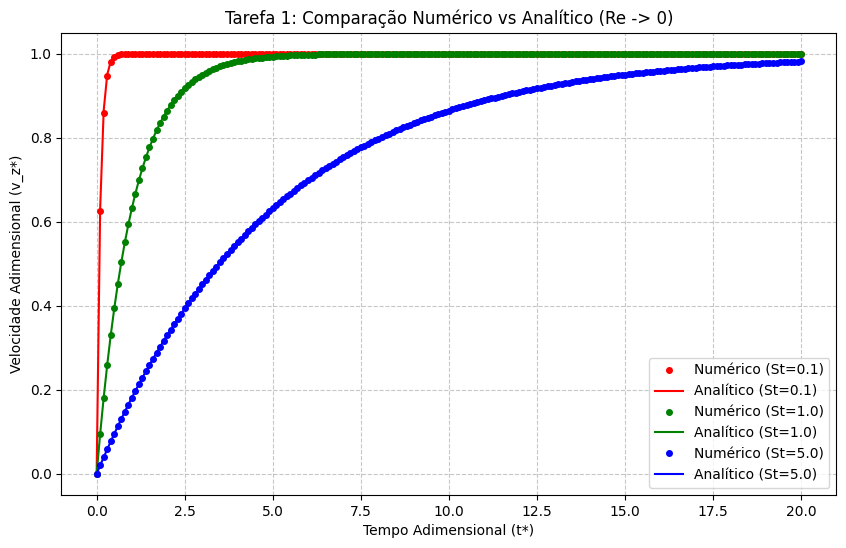

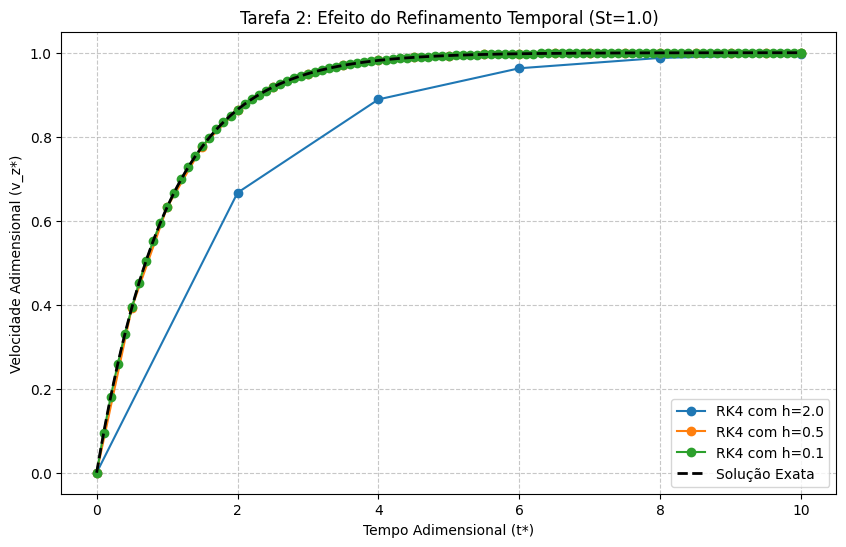

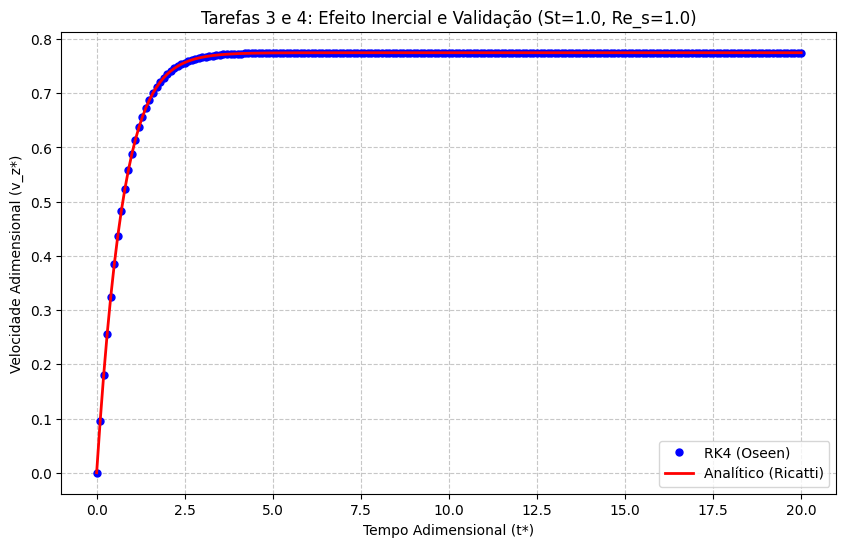

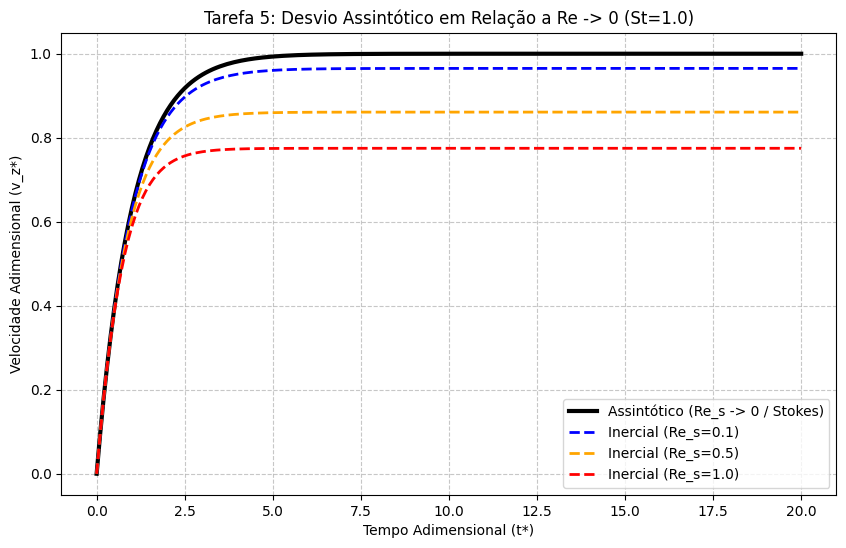

In [ ]:
import math
import matplotlib.pyplot as plt

# =============================================================================
# 1. FUNÇÕES DAS EQUAÇÕES DIFERENCIAIS (DERIVADAS)
# =============================================================================

def derivada_stokes(t, v, St):
  """
    Equação adimensional para o regime de baixo Reynolds (Re -> 0).
    """
  return (1.0-v)/St

def derivada_oseen(t, v, St, Re_s):
  """
    Equação adimensional com efeito inercial (Re != 0).
    """
  return (1.0/St)*(1.0-v-(3.0/8.0)*Re_s*(v**2))

# =============================================================================
# 2. IMPLEMENTAÇÃO DO MÉTODO DE RUNGE-KUTTA DE 4ª ORDEM
# =============================================================================

def rk4(funcao_derivada, v0, t0, t_max, h, **kwargs):
  """
    Resolve uma EDO utilizando o método de Runge-Kutta de 4ª ordem.
    """
  tempos = [t0]
  velocidades = [v0]
  t = t0
  v = v0
  while t < t_max:
    # Garantir que o último passo pare exatamente em t_max
    if t+h > t_max:
      h = t_max-t

    k1 = funcao_derivada(t, v, **kwargs)
    k2 = funcao_derivada(t+h/2.0, v+k1*h/2.0, **kwargs)
    k3 = funcao_derivada(t+h/2.0, v+k2*h/2.0, **kwargs)
    k4 = funcao_derivada(t+h, v+k3*h, **kwargs)

    v = v+(h/6.0)*(k1+2.0*k2+2.0*k3+k4)
    t = t+h

    tempos.append(t)
    velocidades.append(v)

  return tempos, velocidades

# =============================================================================
# 3. SOLUÇÕES ANALÍTICAS (PARA VALIDAÇÃO)
# =============================================================================

def solucao_analitica_stokes(tempos, St):
  """ Solução exata para Re -> 0. """
  return [1.0-math.exp(-t/St) for t in tempos]

def solucao_analitica_oseen(tempos, St, Re_s):
  """ Solução exata da equação de Ricatti para Re != 0. """
  termo_raiz = 1.0+1.5*Re_s
  v_ast = (-1.0+math.sqrt(termo_raiz))/(0.75*Re_s)
  Q = (3.0/(8.0*St))*Re_s
  P = -(3.0/(4.0*St))*Re_s*v_ast-(1.0/St)

  v_exato = []
  for t in tempos:
    termo_exp = math.exp(-P*t)
    colchete = (Q/P)+((-1.0/v_ast)-(Q/P))*termo_exp
    v = v_ast+(1.0/colchete)
    v_exato.append(v)

  return v_exato

# =============================================================================
# 4. RESOLUÇÃO DAS TAREFAS DO PPC E GERAÇÃO DOS GRÁFICOS
# =============================================================================

# Configuração global de tempo da simulação
T_MAX = 20.0
H_PADRAO = 0.1

# -----------------------------------------------------------------------------
# Tarefa 1: Para Re -> 0, compare a solução numérica com a analítica
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
valores_St = [0.1, 1.0, 5.0]
cores = ['r', 'g', 'b']
for St, cor in zip(valores_St, cores):
  t_num, v_num = rk4(derivada_stokes, 0.0, 0.0, T_MAX, H_PADRAO, St=St)
  v_ana = solucao_analitica_stokes(t_num, St)
  plt.plot(t_num, v_num, 'o', color=cor, markersize=4, label=f'Numérico (St={St})')
  plt.plot(t_num, v_ana, '-', color=cor, label=f'Analítico (St={St})')
plt.title('Tarefa 1: Comparação Numérico vs Analítico (Re -> 0)')
plt.xlabel('Tempo Adimensional (t*)')
plt.ylabel('Velocidade Adimensional (v_z*)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# -----------------------------------------------------------------------------
# Tarefa 2: Análise do refinamento temporal (variando h)
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
St_fixo = 1.0
passos_h = [2.0, 0.5, 0.1] # Um passo intencionalmente ruim (2.0) para mostrar o erro
for h in passos_h:
  t_num, v_num = rk4(derivada_stokes, 0.0, 0.0, 10.0, h, St=St_fixo)
  plt.plot(t_num, v_num, '-o', label=f'RK4 com h={h}')

# Plota a analítica como referência (linha preta)
t_ref = [i*0.01 for i in range (1001)] # Tempo bem refinado de 0 a 10
v_ref = solucao_analitica_stokes(t_ref, St_fixo)
plt.plot(t_ref, v_ref, 'k--', linewidth=2, label='Solução Exata')

plt.title('Tarefa 2: Efeito do Refinamento Temporal (St=1.0)')
plt.xlabel('Tempo Adimensional (t*)')
plt.ylabel('Velocidade Adimensional (v_z*)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# -----------------------------------------------------------------------------
# Tarefas 3 e 4: Caso Inercial (Re != 0) e Validação com Equação de Ricatti
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
St_inercial = 1.0
Re_s_teste = 1.0

# Resolução numérica do caso inercial
t_num_inercial, v_num_inercial = rk4(derivada_oseen, 0.0, 0.0, T_MAX, H_PADRAO, St=St_inercial, Re_s=Re_s_teste)

# Validação com a solução analítica
v_ana_inercial = solucao_analitica_oseen(t_num_inercial, St_inercial, Re_s_teste)

plt.plot(t_num_inercial, v_num_inercial, 'bo', markersize=5, label='RK4 (Oseen)')
plt.plot(t_num_inercial, v_ana_inercial, 'r-', linewidth=2, label='Analítico (Ricatti)')

plt.title(f'Tarefas 3 e 4: Efeito Inercial e Validação (St={St_inercial}, Re_s={Re_s_teste})')
plt.xlabel('Tempo Adimensional (t*)')
plt.ylabel('Velocidade Adimensional (v_z*)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# -----------------------------------------------------------------------------
# Tarefa 5: Comportamento da solução e desvio do limite Re -> 0
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
valores_Re_s = [0.1, 0.5, 1.0]

# Referência de Stokes (Re -> 0)
t_ref, v_ref = rk4(derivada_stokes, 0.0, 0.0, T_MAX, H_PADRAO, St=1.0)
plt.plot(t_ref, v_ref, 'k-', linewidth=3, label='Assintótico (Re_s -> 0 / Stokes)')

# Variações do Re_s
cores_re = ['blue', 'orange', 'red']
for Re, cor in zip(valores_Re_s, cores_re):
  t_re, v_re = rk4(derivada_oseen, 0.0, 0.0, T_MAX, H_PADRAO, St=1.0, Re_s=Re)
  plt.plot(t_re, v_re, '--', color=cor, linewidth=2, label=f'Inercial (Re_s={Re})')

plt.title('Tarefa 5: Desvio Assintótico em Relação a Re -> 0 (St=1.0)')
plt.xlabel('Tempo Adimensional (t*)')
plt.ylabel('Velocidade Adimensional (v_z*)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()